# Dynamical System:
Let us consider a dynamical system of the following form:
\begin{align*}
    f(x,u)&=f(x)+g(x)u, \quad \text{where}\\
    f(x)&= \begin{bmatrix}
    -x_1 + x_2 \\
    -0.5 x_1 -0.5x_2 \left ( 1- \left(\cos (2x_1) +2\right)^2 \right)
    \end{bmatrix}, \quad g(x) = \begin{bmatrix}
    0 \\ \cos(2x_1)+2
    \end{bmatrix}
\end{align*}

## Define Density Risk

The control density function risk is:
\begin{align*}
    L(\theta, u) = E \left ( \max (0, \gamma-\rho_{\theta}(x))+\max(0, - \nabla.[\rho_{\theta}(f + gu)(x)])- \gamma\right )
\end{align*}
Using Monte Carlo Estimate,
\begin{align*}
    L(\theta, u) = \frac{1}{N}\sum_{i=1}^{N} \left ( \max (0,-\rho_{\theta}(x))+\max(0, \gamma - \nabla.[\rho_{\theta}(f + gu)(x)])\right )- \gamma
\end{align*}

The SMT constraint is:
\begin{align*}
    \Phi_{\epsilon}(x):=\left (\sum_{i=1}^{n}x_i^2 \geq \epsilon \right ) \wedge \left (\rho(x) \leq 0 \right ) \wedge \left ( \nabla.[\rho_{\theta}(f + gu)(x)] \leq  0 \right )
\end{align*}

In [21]:
import torch

torch.cuda.empty_cache()  # Clear the GPU memory cache


In [22]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt

import random

In [23]:
torch.manual_seed(42)

random.seed()



In [24]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [25]:
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float()
numerical_x = numerical_x.to(device)  

In [26]:


def Checkdivergence(vars,rho_learnt, divergence,  ball_lb, ball_ub, config, epsilon=0):
    """ Checkdivergence takes two necessary arguments which are
     vars and rho_learnt. rho_learnt is basically f \rho - g u \rho.
      we must check if divergence of ( f \rho - g u \rho) > epsilon """
    ball = Expression(0)


    # Construct ball constraint
    ball = vars[0]**2 + vars[1]**2
    ball_in_bound = logical_and(ball_lb <= ball, ball <= ball_ub)

    # Convert rho_learnt to a Formula
    rho_term = rho_learnt > 0

    # Stability conditions: divergence > epsilon and rho > 0
    divergence_condition = divergence > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, rho_term)
    )

    # Check satisfiability of the negation of the condition
    return CheckSatisfiability(logical_not(stability_condition), config)



def AddCounterexamples(x, CE, N, device):
    """
    Adds counterexamples to the sample set `x`.
    
    Args:
        x: Existing tensor of samples.
        CE: Counterexample intervals from `Checkdivergence`.
        N: Number of nearby points to add for each counterexample.
        device: Device where tensors are stored (e.g., `cuda:1`).

    Returns:
        Updated tensor with counterexamples added.
    """
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)  # Generate nearby points
        nearby.append(nearby_)
    
    for i in range(N):
        n_pt = []
        for j in range(x.shape[1]):
            n_pt.append(nearby[j][i])  # Collect one point from each dimension
        # Add the point to `x` on the correct device
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x= torch.unique(x, dim=0)

    return x, n_pt_tensor


In [27]:
import math

def f_value(f_val, g_val, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val * u

def f(x): 
    # Use torch.sin instead of math.sin
    val = torch.tensor([-x[0]+x[1], -0.5*x[0]-0.5*x[1]*(1-(torch.cos(2*x[0])+2)**2)], device=device)
    return val


def g(x):
    return torch.tensor([0, torch.cos(2*x[0])+2], device=device)



In [28]:
import torch.nn as nn

class DensityFunctionNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DensityFunctionNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        
        # Initialize weights to zero and bias to zero (or any desired value)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)

        # Freeze weights to ensure they cannot be updated
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        # Directly return the bias as output
        return self.linear_layer.bias




In [29]:
def gradient_at_given_function(func,x):
    """ The function returns the gradient of given function at x"""
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
   # Compute the output of the function
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Extract scalar from output tensor
    output = output.squeeze()  # Remove batch and channel dimensions (shape: ())
    
    # Ensure the function returns a scalar
    if output.dim() != 0:
        raise ValueError(f"The function must return a scalar value, but got shape {output.shape}.")
    
    # Compute the gradient
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    
    return grad

def div_f(x):

    term = -1 - 0.5*(1-(torch.cos(2*x[0])+2)**2)
    return torch.tensor(term, device=device)


def control_density_risk2(x, rho_in, u_rho_in, fu, gu):
    ret_Val = []
    for i in range(x.shape[0]):
        divergence_at_f = div_f(x[i])
        grad_at_rho = gradient_at_given_function(rho_in, x[i])
        grad_at_u_rho = gradient_at_given_function(u_rho_in, x[i])
        val = rho_in(x[i]) * divergence_at_f + grad_at_rho @ fu(x[i]) + grad_at_u_rho@ gu(x[i]) 
        ret_Val.append(val)
    ret_Val = torch.stack(ret_Val)
    return ret_Val


In [30]:


def control_density_loss(x, rho_in, u_rho_in, fu, gu,gamma):
    divergence2 = control_density_risk2(x,rho_in, u_rho_in, fu, gu)
    loss2 = F.relu(gamma(x)-divergence2).mean()
    rho = rho_in(x)
    rho_loss = F.relu(-rho).mean()
    gamma_loss = F.relu(-gamma(x)).mean()
    return loss2 + rho_loss + gamma_loss




In [31]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

def candidate_constraint_learnt(vars, rho_in, u_rho_in):
    """Compute the candidate constraint"""
    rho = SymbolicNN(rho_in)
    u_rho = SymbolicNN(u_rho_in)
    
    # Get Symbolic Forward Pass
    rho_out = rho.forward_symbolic(vars)
    u_rho_out = u_rho.forward_symbolic(vars)


    # Compute vector field as symbolic expressions
    f_val = [
        -vars[0]+vars[1], 
        (-0.5 *vars[0] - 0.5 * vars[1] * (1 - (cos(2 * vars[0]) + 2)**2))
    ]  # f(x)
    g_val = [0, cos(2*vars[0])+2]  # g(x)

    # Compute f*rho + g*u_rho (element-wise multiplication)
    vector_field = [
        f_val[i] * rho_out[0] + g_val[i] * u_rho_out[0]
        for i in range(len(vars))
    ]

    # Compute divergence as the sum of partial derivatives
    divergence = sum(
        vector_field[i].Differentiate(vars[i])
        for i in range(len(vars))
    )

    return divergence, rho_out[0]



In [32]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
x1 = Variable("x1")
x2 = Variable("x2")


In [33]:
rho_nn = DensityFunctionNet(input_dim=2, hidden_dim=6, output_dim=1).to(device)
u_rho_nn = DensityFunctionNet(input_dim=2, hidden_dim=6, output_dim=1).to(device)
gamma_nn = GammaFunctionNet(input_dim=2, output_dim=1).to(device)

In [34]:

def train_density(x,epochs=2000, learning_rate=1e-1):
    loss_total_density = []
    valid = False


    optimizer = torch.optim.SGD(
        list(rho_nn.parameters()) + list(u_rho_nn.parameters()) + list(gamma_nn.parameters()),
        lr=learning_rate
    )

    # optimizer = torch.optim.Adam(
    #     list(rho_nn.parameters()) + list(u_rho_nn.parameters()) + list(gamma_nn.parameters()),
    #     lr=learning_rate
    # )

    print("Start the training")
    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()

            # compute losses
            loss = control_density_loss(x, rho_nn, u_rho_nn, f,g, gamma_nn)

            # BackPropagation
            loss.backward()
            optimizer.step()

            
            print(f"Epoch : {epoch}, current loss: {loss.item()}")
            loss_total_density.append(loss.item())

            if loss.item() == 0:
                valid = True
                break

            # check counter examples 
            if epoch % 10 == 0 :
                vars = [Variable("x1"), Variable("x2")]
                divergence_learnt, rho_learnt = candidate_constraint_learnt(vars, rho_nn, u_rho_nn)
                result = Checkdivergence(vars, rho_learnt, divergence_learnt,  ball_lb, ball_ub, config,0)

                if (result):
                    print("_______________________________________________________")
                    print("Not a Density function")
                    print(result)
                    x , counter_example = AddCounterexamples(x,result,N=10,device=device)
                    risk_examine = control_density_risk2(counter_example, rho_nn, u_rho_nn, f,g)
                    rho_examine = rho_nn(counter_example)
                    print(f"observe this, {risk_examine}")
                    print(f"observe this, {rho_examine}")
                    print("_______________________________________________________")
                else:
                    valid = True
                    print("Conditions are satisfied!")
                    
    print(f"The learned margin is {gamma_nn(x)}")
    return loss_total_density
        


In [35]:
def plot_results(risks, labels):
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


In [36]:

loss_density = train_density(numerical_x,epochs=2000, learning_rate=1e-1)


Start the training


/tmp/ipykernel_189725/4129087701.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(term, device=device)


Epoch : 0, current loss: 1.0736243724822998
_______________________________________________________
Not a Density function
x1 : [-1.8994020795427777, -1.8993920795427777]
x2 : [1.4578781934144878, 1.4578881934144878]
observe this, tensor([[-0.5610]], grad_fn=<StackBackward0>)
observe this, tensor([[-0.0065]], grad_fn=<AddmmBackward0>)
_______________________________________________________
Epoch : 1, current loss: 0.7810922861099243
Epoch : 2, current loss: 0.6108149290084839
Epoch : 3, current loss: 0.49202847480773926
Epoch : 4, current loss: 0.39884424209594727
Epoch : 5, current loss: 0.35422468185424805
Epoch : 6, current loss: 0.307655930519104
Epoch : 7, current loss: 0.2986633777618408
Epoch : 8, current loss: 0.3464795649051666
Epoch : 9, current loss: 0.26875442266464233
Epoch : 10, current loss: 0.2930047810077667
_______________________________________________________
Not a Density function
x1 : [-1.3476492895403858, -1.3476392895403857]
x2 : [1.193237693252299, 1.193247693

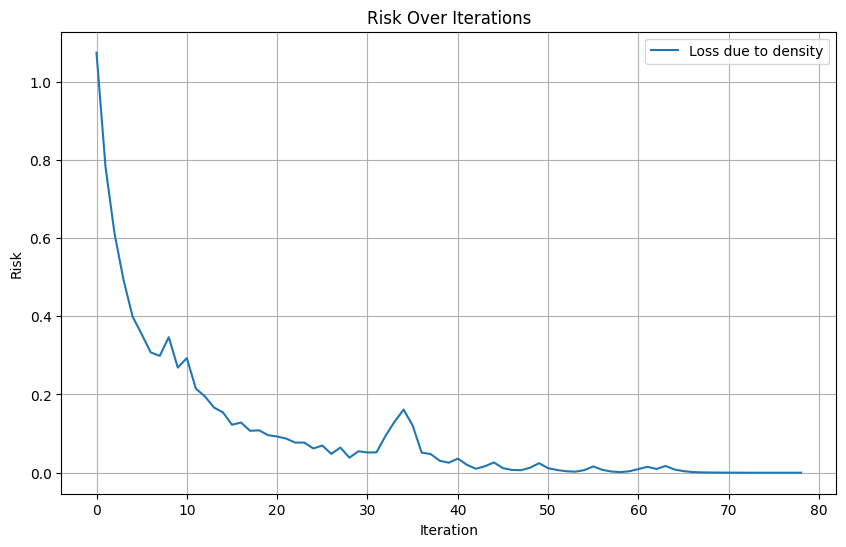

In [37]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [38]:
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)

# Compute divergence set for the grid points
divergence_set = control_density_risk2(grid_points, rho_nn, u_rho_nn, f, g)

# # rescale the value to 1 and -1 for x >=0 and x < 0 respectively
divergence_set = torch.where(divergence_set >= 0, 1, -1)

# Reshape divergence values to match the grid dimensions
divergence_values_reshaped = divergence_set.detach().cpu().numpy().reshape(grid_size, grid_size)





/tmp/ipykernel_189725/4129087701.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(term, device=device)


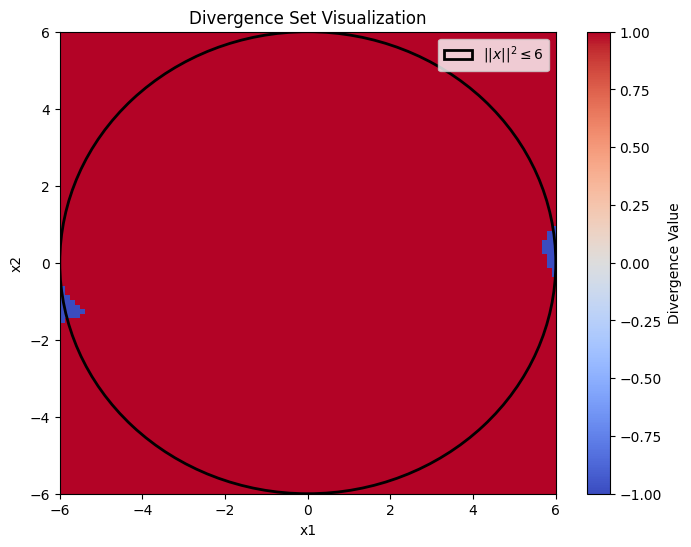

In [39]:
import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    divergence_values_reshaped,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="Divergence Value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Divergence Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [40]:
# Count the total number of values in the divergence set
total_values = divergence_values_reshaped.size

# Count the number of negative values
negative_values_count = (divergence_values_reshaped < 0).sum()

# Calculate the percentage of negative values
percentage_negative = negative_values_count 

print(f"The percentage of negative values in divergence_values_reshaped is {percentage_negative:.2f}")

# # PRINT the negative values taken by the divergence
# negative_values = divergence_values_reshaped[divergence_values_reshaped < 0]
# print(f"The negative values in divergence_values_reshaped are {negative_values}")

The percentage of negative values in divergence_values_reshaped is 43.00
